## Wetness diagnostics (bias / wet fraction / false positives)

This section recomputes diagnostics directly from raw predictions to test the "over-wetting" hypothesis.
Update the paths below to your test PKLs and checkpoint folders before running.


In [1]:
import os, sys, math
import torch, dgl
import numpy as np
import pandas as pd

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.append(ROOT)

from python.create_dgl_dataset import TelemacDataset
from python.CustomMeshGraphNet import MeshGraphNet
from modulus.launch.utils import load_checkpoint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [7]:
# =====================
# Parametres utilisateur (a adapter)
# =====================

DATA_DIR = "/work/m24046/m24046mrcr/paper/Experience2/Multimesh_8_32.bin"
DYNAMIC_DIR = [
    "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Group_1_peak_2600_Group_1_peak_2600_0_0-80_interpolated.pkl",
    "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Group_2_peak_1000_Group_2_peak_1000_0_0-80_interpolated.pkl",
    "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Group_2_peak_1200_Group_2_peak_1200_0_0-80_interpolated.pkl",
    "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Group_2_peak_1600_Group_2_peak_1600_0_0-80_interpolated.pkl",
    "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Group_4_peak_2000_Group_4_peak_2000_0_0-80_interpolated.pkl",
    "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Group_1_peak_1200_Group_1_peak_1200_0_0-80_interpolated.pkl",
    "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Group_1_peak_2400_Group_1_peak_2400_0_0-80_interpolated.pkl",
    "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Group_3_peak_3400_Group_3_peak_3400_0_0-80_interpolated.pkl",
]

HORIZONS_STEPS = list(horizons) if 'horizons' in globals() else [12, 24]
MAX_SEQUENCES = 205
THRESHOLD_M = 0.05
OVERLAP = 1
MASK_BOUNDARY = True  # True = on exclut les BC des stats wet/bias

# Parametres modele (coherents avec l'entrainement)
NUM_INPUT_FEATURES = 9
NUM_EDGE_FEATURES = 3
NUM_OUTPUT_FEATURES = 3
MP_LAYERS = 10
DO_CONCAT_TRICK = True
NUM_PROCESSOR_CHECKPOINT_SEGMENTS = 0

# Checkpoints a comparer
exp_nodice_name = exp_nodice if 'exp_nodice' in globals() else 'nodice'
exp_dice_name = exp_dice if 'exp_dice' in globals() else 'dice'

EXPERIMENTS = {
    exp_nodice_name: {
        'ckpt_dir': '/work/m24046/m24046mrcr/paper/Experience2/Seed0/',
        'epochs': [600, 650, 700, 750, 800,850,900],
    },
    exp_dice_name: {
        'ckpt_dir': '/work/m24046/m24046mrcr/paper/Experience8/Seed0/',
        'epochs': [600, 650, 700, 750, 800,850,900],
    },
}


In [8]:
# =====================
# Fonctions utilitaires
# =====================
def build_model():
    return MeshGraphNet(
        NUM_INPUT_FEATURES,
        NUM_EDGE_FEATURES,
        NUM_OUTPUT_FEATURES,
        processor_size=MP_LAYERS,
        hidden_dim_processor=64,
        hidden_dim_node_encoder=64,
        hidden_dim_edge_encoder=64,
        hidden_dim_node_decoder=64,
        do_concat_trick=DO_CONCAT_TRICK,
        num_processor_checkpoint_segments=NUM_PROCESSOR_CHECKPOINT_SEGMENTS,
    )

def load_model_checkpoint(model, ckpt_dir, epoch):
    load_checkpoint(ckpt_dir, models=model, device=device, epoch=epoch)
    model.to(device)
    model.eval()
    return model

def build_dataset(sequence_length, overlap, ckpt_dir, split="test"):
    return TelemacDataset(
        name=f"eval_{split}",
        data_dir=DATA_DIR,
        dynamic_data_files=DYNAMIC_DIR,
        split=split,
        ckpt_path=ckpt_dir,
        normalize=True,
        sequence_length=sequence_length,
        overlap=overlap,
    )

def _denorm(xn, mean, std):
    return xn * std + mean

def _renorm(x, mean, std):
    return (x - mean) / (std + 1e-12)

def evaluate_model_wetness(model, ds, horizons_steps, max_sequences=10, threshold=0.05, mask_boundary=True):
    stats = ds.node_stats
    dyn_start = ds.base_graph.ndata['static'].shape[1]
    mx = torch.tensor([stats['h'].item(), stats['u'].item(), stats['v'].item()], device=device)
    sx = torch.tensor([stats['h_std'].item(), stats['u_std'].item(), stats['v_std'].item()], device=device)
    dy_mean = torch.tensor([stats['delta_h'].item(), stats['delta_u'].item(), stats['delta_v'].item()], device=device)
    dy_std  = torch.tensor([stats['delta_h_std'].item(), stats['delta_u_std'].item(), stats['delta_v_std'].item()], device=device)

    agg = {h: {
        'count': 0,
        'bias_sum': 0.0,
        'wet_pred_sum': 0,
        'wet_gt_sum': 0,
        'fp_sum': 0,
        'fn_sum': 0,
    } for h in horizons_steps}

    nseq = min(max_sequences, len(ds))
    max_h = max(horizons_steps)

    for idx in range(nseq):
        graphs = ds[idx]
        if len(graphs) <= max_h:
            continue
        g = graphs[0].to(device)
        static_part = g.ndata['x'][:, :dyn_start]
        xn_t = g.ndata['x'][:, dyn_start:dyn_start+3]

        onehot = static_part[:, :4]
        q_mask = (onehot == torch.tensor([0,0,1,0], device=device)).all(dim=1)
        h_mask = (onehot == torch.tensor([0,1,0,0], device=device)).all(dim=1)
        interior_mask = ~(q_mask | h_mask) if mask_boundary else torch.ones_like(q_mask)

        for t in range(max_h):
            with torch.no_grad():
                y_pred_n = model(g.ndata['x'], g.edata['x'], g)
            x_t = _denorm(xn_t, mx, sx)
            y_pred = _denorm(y_pred_n, dy_mean, dy_std)
            x_t1 = x_t + y_pred

            x_gt_n = graphs[t+1].ndata['x'][:, dyn_start:dyn_start+3].to(device)
            x_gt = _denorm(x_gt_n, mx, sx)

            # Conditions limites
            x_t1[q_mask] = x_gt[q_mask]
            x_t1[h_mask, 0:1] = x_gt[h_mask, 0:1]

            step = t + 1
            if step in horizons_steps:
                h_pred = x_t1[:, 0][interior_mask]
                h_gt = x_gt[:, 0][interior_mask]
                if h_pred.numel() == 0:
                    continue

                h_pred_np = h_pred.detach().cpu().numpy()
                h_gt_np = h_gt.detach().cpu().numpy()

                pred_wet = h_pred_np >= threshold
                gt_wet = h_gt_np >= threshold

                n = h_pred_np.size
                agg[step]['count'] += n
                agg[step]['bias_sum'] += float((h_pred_np - h_gt_np).sum())
                agg[step]['wet_pred_sum'] += int(pred_wet.sum())
                agg[step]['wet_gt_sum'] += int(gt_wet.sum())
                agg[step]['fp_sum'] += int(np.logical_and(pred_wet, ~gt_wet).sum())
                agg[step]['fn_sum'] += int(np.logical_and(~pred_wet, gt_wet).sum())

            # reinjection
            xn_t = _renorm(x_t1, mx, sx)
            g = g.clone()
            g.ndata['x'] = torch.cat([static_part, xn_t], dim=1)

    summary = {}
    for h in horizons_steps:
        count = agg[h]['count']
        if count == 0:
            continue
        wet_pred = agg[h]['wet_pred_sum'] / count
        wet_gt = agg[h]['wet_gt_sum'] / count
        summary[h] = {
            'bias_mean': agg[h]['bias_sum'] / count,
            'wet_frac_pred': wet_pred,
            'wet_frac_gt': wet_gt,
            'wet_frac_delta': wet_pred - wet_gt,
            'false_pos_rate': agg[h]['fp_sum'] / count,
            'false_neg_rate': agg[h]['fn_sum'] / count,
        }
    return summary

def run_wet_eval(experiments):
    rows = []
    seq_len = max(HORIZONS_STEPS) + 1
    for exp_name, cfg in experiments.items():
        ckpt_dir = cfg['ckpt_dir']
        epochs = cfg['epochs']
        ds = build_dataset(sequence_length=seq_len, overlap=OVERLAP, ckpt_dir=ckpt_dir)
        for ep in epochs:
            model = build_model()
            load_model_checkpoint(model, ckpt_dir, epoch=ep)
            summary = evaluate_model_wetness(
                model,
                ds,
                HORIZONS_STEPS,
                max_sequences=MAX_SEQUENCES,
                threshold=THRESHOLD_M,
                mask_boundary=MASK_BOUNDARY,
            )
            for h, vals in summary.items():
                rows.append({
                    'exp': exp_name,
                    'epoch': ep,
                    'horizon_steps': h,
                    **vals,
                })
    return pd.DataFrame(rows)


In [9]:
wet_df = run_wet_eval(EXPERIMENTS)
wet_df.sort_values(["exp", "horizon_steps", "epoch"]).head()


[08:17:09 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience2/Seed0/MeshGraphNet.0.600.mdlus to device cuda


Loading normalization statistics...


[08:17:09 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience2/Seed0/checkpoint.0.600.pt to device cuda
[08:17:12 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience2/Seed0/MeshGraphNet.0.650.mdlus to device cuda
[08:17:13 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience2/Seed0/checkpoint.0.650.pt to device cuda
[08:17:16 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience2/Seed0/MeshGraphNet.0.700.mdlus to device cuda
[08:17:16 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience2/Seed0/checkpoint.0.700.pt to device cuda
[08:17:19 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience2/Seed0/MeshGraphNet.0.750.mdlus to device cuda
[08:17:19 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience2/Seed0/checkpoint.0.750.pt to device cuda
[08:1

Loading normalization statistics...


[08:17:31 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience8/Seed0/checkpoint.0.600.pt to device cuda
[08:17:34 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience8/Seed0/MeshGraphNet.0.650.mdlus to device cuda
[08:17:34 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience8/Seed0/checkpoint.0.650.pt to device cuda
[08:17:37 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience8/Seed0/MeshGraphNet.0.700.mdlus to device cuda
[08:17:37 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience8/Seed0/checkpoint.0.700.pt to device cuda
[08:17:40 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience8/Seed0/MeshGraphNet.0.750.mdlus to device cuda
[08:17:40 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience8/Seed0/checkpoint.0.750.pt to device cuda
[08:1

,exp,epoch,horizon_steps,bias_mean,wet_frac_pred,wet_frac_gt,wet_frac_delta,false_pos_rate,false_neg_rate
14,dice,600,12,-0.383205,0.211667,0.327376,-0.115709,0.017029,0.132738
16,dice,650,12,-0.233702,0.239804,0.327376,-0.087572,0.017585,0.105157
18,dice,700,12,-0.192424,0.266163,0.327376,-0.061213,0.026629,0.087842
20,dice,750,12,-0.212256,0.256764,0.327376,-0.070613,0.020585,0.091197
22,dice,800,12,-0.144527,0.327167,0.327376,-0.000209,0.055663,0.055872


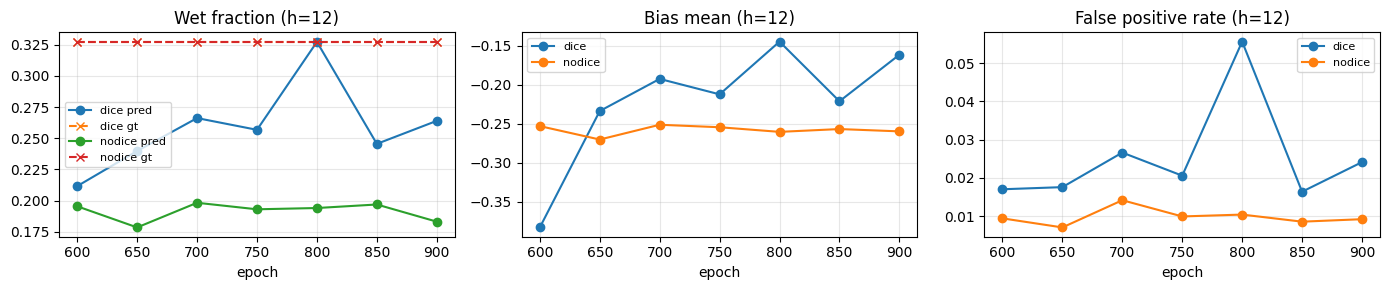

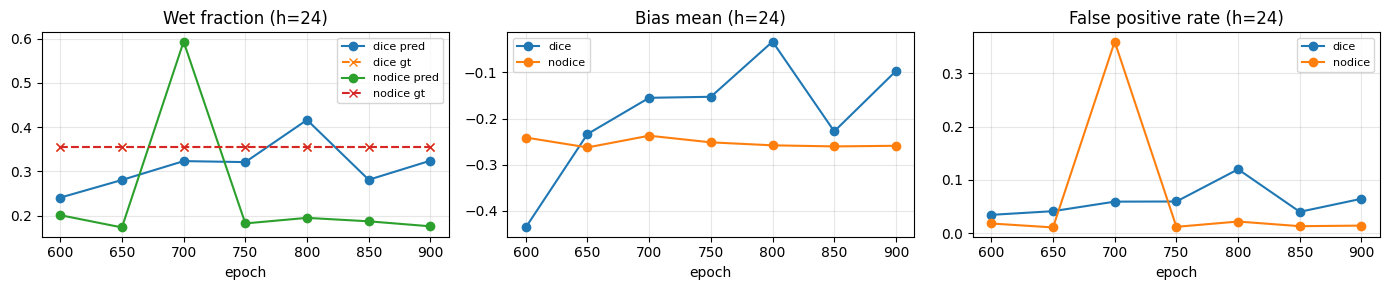

In [10]:
import matplotlib.pyplot as plt

def plot_wet_metrics(df, horizons_steps):
    for h in horizons_steps:
        sub = df[df["horizon_steps"].eq(h)]
        if sub.empty:
            continue
        fig, axes = plt.subplots(1, 3, figsize=(14, 3), sharex=True)
        for exp_name, g in sub.groupby("exp"):
            g = g.sort_values("epoch")
            axes[0].plot(g["epoch"], g["wet_frac_pred"], marker="o", label=f"{exp_name} pred")
            axes[0].plot(g["epoch"], g["wet_frac_gt"], marker="x", linestyle="--", label=f"{exp_name} gt")
            axes[1].plot(g["epoch"], g["bias_mean"], marker="o", label=exp_name)
            axes[2].plot(g["epoch"], g["false_pos_rate"], marker="o", label=exp_name)

        axes[0].set_title(f"Wet fraction (h={h})")
        axes[1].set_title(f"Bias mean (h={h})")
        axes[2].set_title(f"False positive rate (h={h})")

        for ax in axes:
            ax.grid(True, alpha=0.3)
            ax.set_xlabel("epoch")
        axes[0].legend(loc="best", fontsize=8)
        axes[1].legend(loc="best", fontsize=8)
        axes[2].legend(loc="best", fontsize=8)
        plt.tight_layout()
        plt.show()

plot_wet_metrics(wet_df, HORIZONS_STEPS)


In [11]:
wet_df

,exp,epoch,horizon_steps,bias_mean,wet_frac_pred,wet_frac_gt,wet_frac_delta,false_pos_rate,false_neg_rate
0,nodice,600,12,-0.253053,0.195535,0.327376,-0.131841,0.009415,0.141256
1,nodice,600,24,-0.241111,0.201232,0.354137,-0.152905,0.018320,0.171225
2,nodice,650,12,-0.270294,0.178614,0.327376,-0.148762,0.007042,0.155804
3,nodice,650,24,-0.262589,0.173520,0.354137,-0.180617,0.010938,0.191554
4,nodice,700,12,-0.251312,0.198357,0.327376,-0.129020,0.014161,0.143181
5,nodice,700,24,-0.237195,0.593099,0.354137,0.238962,0.359007,0.120045
6,nodice,750,12,-0.254507,0.193131,0.327376,-0.134245,0.009917,0.144162
7,nodice,750,24,-0.251568,0.182572,0.354137,-0.171565,0.012051,0.183616
8,nodice,800,12,-0.260445,0.194159,0.327376,-0.133217,0.010404,0.143621
9,nodice,800,24,-0.258040,0.195118,0.354137,-0.159019,0.021984,0.181003


In [11]:
# --- bias_mean_gtwet par tranches de h_gt (bins) ---
# Ajoute ça après tes fonctions, puis relance pour un ou plusieurs checkpoints.

# Bins en mètres (à adapter)
HGT_BINS = [0.05, 0.10, 0.20, 0.50, 1.0, 2.0, 5.0, np.inf]
BIN_LABELS = [f"[{HGT_BINS[i]:.2f},{HGT_BINS[i+1]:.2f})" if np.isfinite(HGT_BINS[i+1]) else f"[{HGT_BINS[i]:.2f},inf)"
              for i in range(len(HGT_BINS)-1)]

def evaluate_bias_by_hgt_bins(model, ds, horizons_steps, max_sequences=10, threshold=0.05, hgt_bins=None, mask_boundary=True):
    if hgt_bins is None:
        hgt_bins = [threshold, 0.10, 0.20, 0.50, 1.0, 2.0, 5.0, np.inf]

    stats = ds.node_stats
    dyn_start = ds.base_graph.ndata["static"].shape[1]
    mx = torch.tensor([stats["h"].item(), stats["u"].item(), stats["v"].item()], device=device)
    sx = torch.tensor([stats["h_std"].item(), stats["u_std"].item(), stats["v_std"].item()], device=device)
    dy_mean = torch.tensor([stats["delta_h"].item(), stats["delta_u"].item(), stats["delta_v"].item()], device=device)
    dy_std  = torch.tensor([stats["delta_h_std"].item(), stats["delta_u_std"].item(), stats["delta_v_std"].item()], device=device)

    # agg[step][bin_idx] = {"count":..., "bias_sum":...}
    agg = {h: [{"count": 0, "bias_sum": 0.0} for _ in range(len(hgt_bins)-1)] for h in horizons_steps}

    nseq = min(max_sequences, len(ds))
    max_h = max(horizons_steps)

    for idx in range(nseq):
        graphs = ds[idx]
        if len(graphs) <= max_h:
            continue

        g = graphs[0].to(device)
        static_part = g.ndata["x"][:, :dyn_start]
        xn_t = g.ndata["x"][:, dyn_start : dyn_start + 3]

        onehot = static_part[:, :4]
        q_mask = (onehot == torch.tensor([0, 0, 1, 0], device=device)).all(dim=1)
        h_mask = (onehot == torch.tensor([0, 1, 0, 0], device=device)).all(dim=1)
        interior_mask = ~(q_mask | h_mask) if mask_boundary else torch.ones_like(q_mask)

        for t in range(max_h):
            with torch.no_grad():
                y_pred_n = model(g.ndata["x"], g.edata["x"], g)

            x_t = _denorm(xn_t, mx, sx)
            y_pred = _denorm(y_pred_n, dy_mean, dy_std)
            x_t1 = x_t + y_pred

            x_gt_n = graphs[t + 1].ndata["x"][:, dyn_start : dyn_start + 3].to(device)
            x_gt = _denorm(x_gt_n, mx, sx)

            # BC
            x_t1[q_mask] = x_gt[q_mask]
            x_t1[h_mask, 0:1] = x_gt[h_mask, 0:1]

            step = t + 1
            if step in horizons_steps:
                h_pred = x_t1[:, 0][interior_mask]
                h_gt   = x_gt[:, 0][interior_mask]
                if h_pred.numel() == 0:
                    continue

                hp = h_pred.detach().cpu().numpy()
                hg = h_gt.detach().cpu().numpy()
                diff = hp - hg

                # On ne garde que les points gt mouillés (>= threshold)
                wet = hg >= threshold
                if not wet.any():
                    pass
                else:
                    hg_w = hg[wet]
                    diff_w = diff[wet]

                    for b in range(len(hgt_bins)-1):
                        lo, hi = hgt_bins[b], hgt_bins[b+1]
                        m = (hg_w >= lo) & (hg_w < hi)
                        if m.any():
                            agg[step][b]["count"] += int(m.sum())
                            agg[step][b]["bias_sum"] += float(diff_w[m].sum())

            # reinjection
            xn_t = _renorm(x_t1, mx, sx)
            g = g.clone()
            g.ndata["x"] = torch.cat([static_part, xn_t], dim=1)

    # format en DataFrame long
    rows = []
    for step in horizons_steps:
        for b in range(len(hgt_bins)-1):
            c = agg[step][b]["count"]
            rows.append({
                "horizon_steps": step,
                "hgt_bin": f"[{hgt_bins[b]:.2f},{hgt_bins[b+1]:.2f})" if np.isfinite(hgt_bins[b+1]) else f"[{hgt_bins[b]:.2f},inf)",
                "count": c,
                "bias_mean_gtwet_bin": (agg[step][b]["bias_sum"] / c) if c > 0 else np.nan,
            })
    return pd.DataFrame(rows)

def run_bias_bins(EXPERIMENTS, hgt_bins=None):
    rows = []
    seq_len = max(HORIZONS_STEPS) + 1
    for exp_name, cfg in EXPERIMENTS.items():
        ckpt_dir = cfg["ckpt_dir"]
        epochs = cfg["epochs"]
        ds = build_dataset(sequence_length=seq_len, overlap=OVERLAP, ckpt_dir=ckpt_dir)
        for ep in epochs:
            model = build_model()
            load_model_checkpoint(model, ckpt_dir, epoch=ep)
            df_bins = evaluate_bias_by_hgt_bins(
                model, ds, HORIZONS_STEPS,
                max_sequences=MAX_SEQUENCES,
                threshold=THRESHOLD_M,
                hgt_bins=hgt_bins or HGT_BINS,
                mask_boundary=MASK_BOUNDARY,
            )
            df_bins["exp"] = exp_name
            df_bins["epoch"] = ep
            rows.append(df_bins)
    return pd.concat(rows, ignore_index=True)

bias_bins_df = run_bias_bins(EXPERIMENTS, hgt_bins=HGT_BINS)

# aperçu


[20:11:35 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience1/Seed0/MeshGraphNet.0.600.mdlus to device cuda


Loading normalization statistics...


[20:11:35 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience1/Seed0/checkpoint.0.600.pt to device cuda
[20:11:38 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience1/Seed0/MeshGraphNet.0.650.mdlus to device cuda
[20:11:38 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience1/Seed0/checkpoint.0.650.pt to device cuda
[20:11:41 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience1/Seed0/MeshGraphNet.0.700.mdlus to device cuda
[20:11:41 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience1/Seed0/checkpoint.0.700.pt to device cuda
[20:11:44 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience1/Seed0/MeshGraphNet.0.750.mdlus to device cuda
[20:11:44 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience1/Seed0/checkpoint.0.750.pt to device cuda
[20:1

In [13]:
bias_bins_df.to_csv("test wetness", encoding='utf-8', index=False)

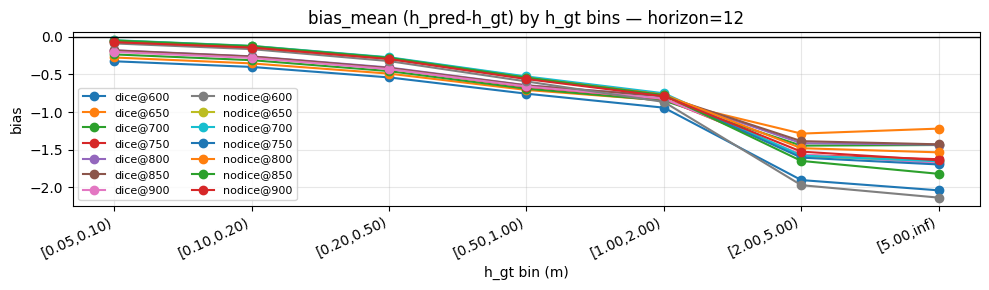

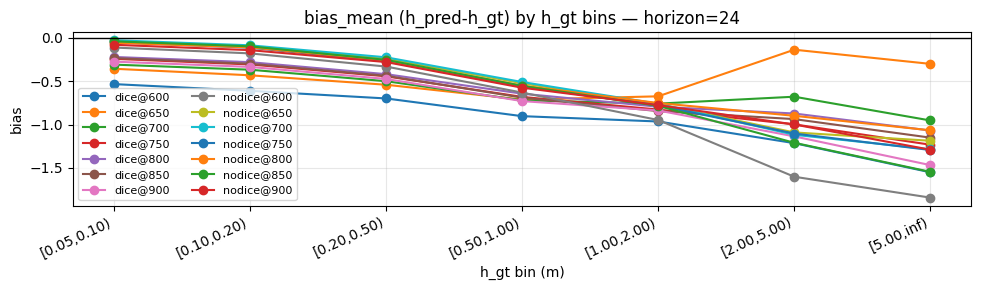

In [10]:
# (optionnel) plot : biais par bin, séparé par horizon

for h in sorted(bias_bins_df["horizon_steps"].unique()):
    sub = bias_bins_df[bias_bins_df["horizon_steps"].eq(h)].copy()
    if sub.empty:
        continue
    fig, ax = plt.subplots(figsize=(10, 3))
    for (exp_name, ep), g in sub.groupby(["exp","epoch"]):
        ax.plot(g["hgt_bin"], g["bias_mean_gtwet_bin"], marker="o", label=f"{exp_name}@{ep}")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"bias_mean (h_pred-h_gt) by h_gt bins — horizon={h}")
    ax.set_ylabel("bias")
    ax.set_xlabel("h_gt bin (m)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=2)
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()
